<a href="https://colab.research.google.com/github/PETEROA/ML-Optimization-Daily/blob/main/mobilenet_efficientnet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Here, I  implement the two most influential efficient CNN families: MobileNet and EfficientNet. MobileNetV1 introduced depthwise separable convolutions for mobile deployment. MobileNetV2 added inverted residuals and linear bottlenecks. MobileNetV3 combined NAS-discovered architectures with squeeze-and-excitation and h-swish activations. EfficientNet introduced compound scaling—systematically scaling depth, width, and resolution together using a single coefficient. I implement each architecture from scratch, analyse its design principles, compare efficiency metrics (params, FLOPs, latency), and train on CIFAR-10. Understanding these architectures is essential as they form the backbone of mobile vision systems and the search space for neural architecture search.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
from typing import Optional, List, Dict, Tuple, Union, Callable
from dataclasses import dataclass
from functools import partial
import math
import time

In [2]:
# Utility functions
def count_parameters(model: nn.Module) -> int:
    """Count trainable parameters."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def count_flops(model: nn.Module, input_size: Tuple[int, ...]) -> int:
    """
    Estimate FLOPs for a model.
    Simplified counting - actual FLOPs depend on implementation.
    """
    total_flops = 0

    def hook_fn(module, input, output):
        nonlocal total_flops

        if isinstance(module, nn.Conv2d):
            # FLOPs = 2 * Cout * Hout * Wout * Cin * K * K / groups
            out_h, out_w = output.shape[2], output.shape[3]
            flops = 2 * module.out_channels * out_h * out_w * \
                    module.in_channels * module.kernel_size[0] * module.kernel_size[1] // module.groups
            total_flops += flops

        elif isinstance(module, nn.Linear):
            # FLOPs = 2 * in_features * out_features
            flops = 2 * module.in_features * module.out_features
            total_flops += flops

    hooks = []
    for module in model.modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            hooks.append(module.register_forward_hook(hook_fn))

    x = torch.randn(1, *input_size)
    model.eval()
    with torch.no_grad():
        model(x)

    for hook in hooks:
        hook.remove()

    return total_flops


def make_divisible(v: float, divisor: int = 8, min_value: Optional[int] = None) -> int:
    """
    Ensure channel count is divisible by divisor.
    Used for hardware-friendly channel counts.
    """
    if min_value is None:
        min_value = divisor
    new_v = max(min_value, int(v + divisor / 2) // divisor * divisor)
    if new_v < 0.9 * v:
        new_v += divisor
    return new_v

MobileNetV1

MobileNetV1 introduced depthwise separable convolutions as a drop-in replacement for standard convolutions.

Architecture: Standard conv - 13 depthwise separable blocks - Global pool - FC

Width Multiplier: Scales all channel counts by α (0.25, 0.5, 0.75, 1.0)

Resolution Multiplier: Scales input resolution (128, 160, 192, 224)

In [3]:
class DepthwiseSeparableConv(nn.Module):
    """
    Depthwise Separable Convolution block (MobileNetV1 style).

    Structure:
    - Depthwise conv (3x3, groups=in_channels)
    - BatchNorm + ReLU
    - Pointwise conv (1x1)
    - BatchNorm + ReLU
    """

    def __init__(self, in_channels: int, out_channels: int, stride: int = 1):
        super().__init__()

        self.depthwise = nn.Sequential(
            nn.Conv2d(in_channels, in_channels, 3, stride=stride,
                     padding=1, groups=in_channels, bias=False),
            nn.BatchNorm2d(in_channels),
            nn.ReLU(inplace=True)
        )

        self.pointwise = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.depthwise(x)
        x = self.pointwise(x)
        return x


class MobileNetV1(nn.Module):
    """
    MobileNetV1: Efficient CNN using depthwise separable convolutions.

    Args:
        num_classes: Number of output classes
        width_mult: Width multiplier (0.25, 0.5, 0.75, 1.0)
        input_channels: Number of input channels (3 for RGB)
    """

    # (out_channels, stride)
    CFG = [
        (64, 1),
        (128, 2), (128, 1),
        (256, 2), (256, 1),
        (512, 2), (512, 1), (512, 1), (512, 1), (512, 1), (512, 1),
        (1024, 2), (1024, 1)
    ]

    def __init__(self, num_classes: int = 1000, width_mult: float = 1.0,
                 input_channels: int = 3):
        super().__init__()

        self.width_mult = width_mult

        # First layer: standard conv
        first_channels = make_divisible(32 * width_mult)
        self.first_conv = nn.Sequential(
            nn.Conv2d(input_channels, first_channels, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(first_channels),
            nn.ReLU(inplace=True)
        )

        # Build depthwise separable blocks
        layers = []
        in_channels = first_channels

        for out_channels, stride in self.CFG:
            out_channels = make_divisible(out_channels * width_mult)
            layers.append(DepthwiseSeparableConv(in_channels, out_channels, stride))
            in_channels = out_channels

        self.features = nn.Sequential(*layers)

        # Classifier
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Linear(in_channels, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.first_conv(x)
        x = self.features(x)
        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

In [4]:
# Test MobileNetV1

print("MobileNetV1 Variants")
print("=" * 60)

for width_mult in [0.25, 0.5, 0.75, 1.0]:
    model = MobileNetV1(num_classes=1000, width_mult=width_mult)
    params = count_parameters(model)
    flops = count_flops(model, (3, 224, 224))

    print(f"\nMobileNetV1 (α={width_mult}):")
    print(f"  Parameters: {params / 1e6:.2f}M")
    print(f"  FLOPs: {flops / 1e6:.1f}M")

MobileNetV1 Variants

MobileNetV1 (α=0.25):
  Parameters: 0.47M
  FLOPs: 82.1M

MobileNetV1 (α=0.5):
  Parameters: 1.33M
  FLOPs: 299.0M

MobileNetV1 (α=0.75):
  Parameters: 2.59M
  FLOPs: 650.8M

MobileNetV1 (α=1.0):
  Parameters: 4.23M
  FLOPs: 1137.5M


MobileNetV2

MobileNetV2 (Sandler et al., 2018) introduced two key innovations:
Inverted Residuals: Expand → Depthwise → Project (opposite of ResNet bottleneck)
Linear Bottlenecks: No ReLU after projection (preserves information in low-dim space)

In [5]:
class InvertedResidual(nn.Module):
    """
    Inverted Residual Block (MobileNetV2).

    Structure:
    1. Expand: 1x1 conv (in_channels → expand_channels)
    2. Depthwise: 3x3 depthwise conv
    3. Project: 1x1 conv (expand_channels → out_channels) - LINEAR (no ReLU!)

    Residual connection if stride=1 and in_channels=out_channels.
    """

    def __init__(self, in_channels: int, out_channels: int,
                 stride: int = 1, expand_ratio: float = 6.0):
        super().__init__()

        self.stride = stride
        self.use_residual = (stride == 1 and in_channels == out_channels)

        hidden_dim = int(in_channels * expand_ratio)

        layers = []

        # Expand (skip if expand_ratio == 1)
        if expand_ratio != 1:
            layers.extend([
                nn.Conv2d(in_channels, hidden_dim, 1, bias=False),
                nn.BatchNorm2d(hidden_dim),
                nn.ReLU6(inplace=True)
            ])

        # Depthwise
        layers.extend([
            nn.Conv2d(hidden_dim, hidden_dim, 3, stride=stride,
                     padding=1, groups=hidden_dim, bias=False),
            nn.BatchNorm2d(hidden_dim),
            nn.ReLU6(inplace=True)
        ])

        # Project (LINEAR - no activation!)
        layers.extend([
            nn.Conv2d(hidden_dim, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels)
            # No ReLU here - this is the "linear bottleneck"
        ])

        self.conv = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if self.use_residual:
            return x + self.conv(x)
        else:
            return self.conv(x)


class MobileNetV2(nn.Module):
    """
    MobileNetV2: Inverted Residuals and Linear Bottlenecks.

    Args:
        num_classes: Number of output classes
        width_mult: Width multiplier
        input_channels: Input channels
    """

    # (expand_ratio, out_channels, num_blocks, stride)
    CFG = [
        (1, 16, 1, 1),
        (6, 24, 2, 2),
        (6, 32, 3, 2),
        (6, 64, 4, 2),
        (6, 96, 3, 1),
        (6, 160, 3, 2),
        (6, 320, 1, 1),
    ]

    def __init__(self, num_classes: int = 1000, width_mult: float = 1.0,
                 input_channels: int = 3):
        super().__init__()

        # First conv
        first_channels = make_divisible(32 * width_mult)
        self.first_conv = nn.Sequential(
            nn.Conv2d(input_channels, first_channels, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(first_channels),
            nn.ReLU6(inplace=True)
        )

        # Build inverted residual blocks
        layers = []
        in_channels = first_channels

        for expand_ratio, out_channels, num_blocks, stride in self.CFG:
            out_channels = make_divisible(out_channels * width_mult)

            for i in range(num_blocks):
                s = stride if i == 0 else 1
                layers.append(InvertedResidual(in_channels, out_channels, s, expand_ratio))
                in_channels = out_channels

        self.features = nn.Sequential(*layers)

        # Last conv
        last_channels = make_divisible(1280 * width_mult) if width_mult > 1.0 else 1280
        self.last_conv = nn.Sequential(
            nn.Conv2d(in_channels, last_channels, 1, bias=False),
            nn.BatchNorm2d(last_channels),
            nn.ReLU6(inplace=True)
        )

        # Classifier
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(last_channels, num_classes)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.first_conv(x)
        x = self.features(x)
        x = self.last_conv(x)
        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

In [6]:
# Test MobileNetV2

print("MobileNetV2 Variants")
print("=" * 60)

for width_mult in [0.35, 0.5, 0.75, 1.0, 1.4]:
    model = MobileNetV2(num_classes=1000, width_mult=width_mult)
    params = count_parameters(model)
    flops = count_flops(model, (3, 224, 224))

    print(f"\nMobileNetV2 (α={width_mult}):")
    print(f"  Parameters: {params / 1e6:.2f}M")
    print(f"  FLOPs: {flops / 1e6:.1f}M")

MobileNetV2 Variants

MobileNetV2 (α=0.35):
  Parameters: 1.68M
  FLOPs: 118.6M

MobileNetV2 (α=0.5):
  Parameters: 1.97M
  FLOPs: 194.3M

MobileNetV2 (α=0.75):
  Parameters: 2.64M
  FLOPs: 418.1M

MobileNetV2 (α=1.0):
  Parameters: 3.50M
  FLOPs: 601.5M

MobileNetV2 (α=1.4):
  Parameters: 6.11M
  FLOPs: 1164.4M


MobileNetV3

MobileNetV3 combines:

1. NAS-discovered architecture: Block configurations found by architecture search
2. Squeeze-and-Excitation (SE): Channel attention in each block
3. h-swish activation: x * ReLU6(x + 3) / 6 — hardware-friendly approximation of swish
4. Redesigned head: Efficient last stage with reduced computation

In [7]:
class HSwish(nn.Module):
    """Hard Swish activation: x * ReLU6(x + 3) / 6"""

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x * F.relu6(x + 3, inplace=True) / 6


class HSigmoid(nn.Module):
    """Hard Sigmoid: ReLU6(x + 3) / 6"""

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return F.relu6(x + 3, inplace=True) / 6


class SEBlock(nn.Module):
    """
    Squeeze-and-Excitation block.

    Channel attention mechanism:
    1. Squeeze: Global average pooling
    2. Excitation: FC → ReLU → FC → Sigmoid
    3. Scale: Element-wise multiplication
    """

    def __init__(self, channels: int, reduction: int = 4):
        super().__init__()

        reduced = make_divisible(channels // reduction)

        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc1 = nn.Conv2d(channels, reduced, 1)  # Use conv for efficiency
        self.fc2 = nn.Conv2d(reduced, channels, 1)
        self.act = nn.ReLU(inplace=True)
        self.gate = HSigmoid()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        scale = self.pool(x)
        scale = self.act(self.fc1(scale))
        scale = self.gate(self.fc2(scale))
        return x * scale


class MobileNetV3Block(nn.Module):
    """
    MobileNetV3 building block.

    Inverted residual with optional SE and configurable activation.
    """

    def __init__(self, in_channels: int, out_channels: int, kernel_size: int,
                 stride: int, expand_ratio: float, use_se: bool = True,
                 activation: str = 'relu'):
        super().__init__()

        self.use_residual = (stride == 1 and in_channels == out_channels)
        hidden_dim = make_divisible(in_channels * expand_ratio)

        # Activation
        if activation == 'relu':
            act = nn.ReLU(inplace=True)
        elif activation == 'hswish':
            act = HSwish()
        else:
            act = nn.ReLU(inplace=True)

        layers = []

        # Expand
        if expand_ratio != 1:
            layers.extend([
                nn.Conv2d(in_channels, hidden_dim, 1, bias=False),
                nn.BatchNorm2d(hidden_dim),
                act
            ])

        # Depthwise
        padding = (kernel_size - 1) // 2
        layers.extend([
            nn.Conv2d(hidden_dim, hidden_dim, kernel_size, stride=stride,
                     padding=padding, groups=hidden_dim, bias=False),
            nn.BatchNorm2d(hidden_dim),
            act
        ])

        self.conv = nn.Sequential(*layers)

        # SE
        self.se = SEBlock(hidden_dim) if use_se else nn.Identity()

        # Project
        self.project = nn.Sequential(
            nn.Conv2d(hidden_dim, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = self.conv(x)
        out = self.se(out)
        out = self.project(out)

        if self.use_residual:
            return x + out
        return out


class MobileNetV3(nn.Module):
    """
    MobileNetV3: NAS-discovered efficient architecture.

    Args:
        mode: 'large' or 'small'
        num_classes: Number of output classes
        width_mult: Width multiplier
    """

    # (kernel, expand, out, se, activation, stride)
    CFG_LARGE = [
        (3, 1, 16, False, 'relu', 1),
        (3, 4, 24, False, 'relu', 2),
        (3, 3, 24, False, 'relu', 1),
        (5, 3, 40, True, 'relu', 2),
        (5, 3, 40, True, 'relu', 1),
        (5, 3, 40, True, 'relu', 1),
        (3, 6, 80, False, 'hswish', 2),
        (3, 2.5, 80, False, 'hswish', 1),
        (3, 2.3, 80, False, 'hswish', 1),
        (3, 2.3, 80, False, 'hswish', 1),
        (3, 6, 112, True, 'hswish', 1),
        (3, 6, 112, True, 'hswish', 1),
        (5, 6, 160, True, 'hswish', 2),
        (5, 6, 160, True, 'hswish', 1),
        (5, 6, 160, True, 'hswish', 1),
    ]

    CFG_SMALL = [
        (3, 1, 16, True, 'relu', 2),
        (3, 4.5, 24, False, 'relu', 2),
        (3, 3.67, 24, False, 'relu', 1),
        (5, 4, 40, True, 'hswish', 2),
        (5, 6, 40, True, 'hswish', 1),
        (5, 6, 40, True, 'hswish', 1),
        (5, 3, 48, True, 'hswish', 1),
        (5, 3, 48, True, 'hswish', 1),
        (5, 6, 96, True, 'hswish', 2),
        (5, 6, 96, True, 'hswish', 1),
        (5, 6, 96, True, 'hswish', 1),
    ]

    def __init__(self, mode: str = 'large', num_classes: int = 1000,
                 width_mult: float = 1.0, input_channels: int = 3):
        super().__init__()

        cfg = self.CFG_LARGE if mode == 'large' else self.CFG_SMALL

        # First conv
        first_channels = make_divisible(16 * width_mult)
        self.first_conv = nn.Sequential(
            nn.Conv2d(input_channels, first_channels, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(first_channels),
            HSwish()
        )

        # Build blocks
        layers = []
        in_channels = first_channels

        for kernel, expand, out, se, act, stride in cfg:
            out_channels = make_divisible(out * width_mult)
            layers.append(MobileNetV3Block(
                in_channels, out_channels, kernel, stride, expand, se, act
            ))
            in_channels = out_channels

        self.features = nn.Sequential(*layers)

        # Efficient last stage
        last_channels = make_divisible(960 * width_mult) if mode == 'large' else make_divisible(576 * width_mult)
        self.last_conv = nn.Sequential(
            nn.Conv2d(in_channels, last_channels, 1, bias=False),
            nn.BatchNorm2d(last_channels),
            HSwish()
        )

        # Classifier (efficient head)
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        final_channels = 1280 if mode == 'large' else 1024
        self.classifier = nn.Sequential(
            nn.Linear(last_channels, final_channels),
            HSwish(),
            nn.Dropout(0.2),
            nn.Linear(final_channels, num_classes)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.first_conv(x)
        x = self.features(x)
        x = self.last_conv(x)
        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

In [8]:
# Test MobileNetV3

print("MobileNetV3 Variants")
print("=" * 60)

for mode in ['large', 'small']:
    for width_mult in [0.75, 1.0]:
        model = MobileNetV3(mode=mode, num_classes=1000, width_mult=width_mult)
        params = count_parameters(model)
        flops = count_flops(model, (3, 224, 224))

        print(f"\nMobileNetV3-{mode.capitalize()} (α={width_mult}):")
        print(f"  Parameters: {params / 1e6:.2f}M")
        print(f"  FLOPs: {flops / 1e6:.1f}M")

MobileNetV3 Variants

MobileNetV3-Large (α=0.75):
  Parameters: 3.99M
  FLOPs: 309.1M

MobileNetV3-Large (α=1.0):
  Parameters: 5.48M
  FLOPs: 433.2M

MobileNetV3-Small (α=0.75):
  Parameters: 2.04M
  FLOPs: 86.8M

MobileNetV3-Small (α=1.0):
  Parameters: 2.54M
  FLOPs: 113.0M


EfficientNet

EfficientNet introduced compound scaling

In [9]:
class MBConv(nn.Module):
    """
    Mobile Inverted Bottleneck Conv (MBConv) for EfficientNet.

    Same as MobileNetV3 block but with:
    - Swish (SiLU) activation instead of h-swish
    - Stochastic depth (drop path)
    """

    def __init__(self, in_channels: int, out_channels: int, kernel_size: int,
                 stride: int, expand_ratio: float, se_ratio: float = 0.25,
                 drop_path_rate: float = 0.0):
        super().__init__()

        self.use_residual = (stride == 1 and in_channels == out_channels)
        self.drop_path_rate = drop_path_rate

        hidden_dim = make_divisible(in_channels * expand_ratio)

        layers = []

        # Expand
        if expand_ratio != 1:
            layers.extend([
                nn.Conv2d(in_channels, hidden_dim, 1, bias=False),
                nn.BatchNorm2d(hidden_dim),
                nn.SiLU(inplace=True)
            ])

        # Depthwise
        padding = (kernel_size - 1) // 2
        layers.extend([
            nn.Conv2d(hidden_dim, hidden_dim, kernel_size, stride=stride,
                     padding=padding, groups=hidden_dim, bias=False),
            nn.BatchNorm2d(hidden_dim),
            nn.SiLU(inplace=True)
        ])

        self.conv = nn.Sequential(*layers)

        # SE
        se_channels = max(1, int(in_channels * se_ratio))
        self.se = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(hidden_dim, se_channels, 1),
            nn.SiLU(inplace=True),
            nn.Conv2d(se_channels, hidden_dim, 1),
            nn.Sigmoid()
        )

        # Project
        self.project = nn.Sequential(
            nn.Conv2d(hidden_dim, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = self.conv(x)
        out = out * self.se(out)  # SE attention
        out = self.project(out)

        if self.use_residual:
            # Stochastic depth
            if self.training and self.drop_path_rate > 0:
                if torch.rand(1).item() < self.drop_path_rate:
                    return x
            return x + out
        return out


@dataclass
class EfficientNetConfig:
    """Configuration for EfficientNet variants."""
    width_mult: float
    depth_mult: float
    resolution: int
    dropout: float


class EfficientNet(nn.Module):
    """
    EfficientNet: Compound Scaling for CNNs.

    Base architecture (B0) found by NAS. B1-B7 are scaled versions.
    """

    # (expand_ratio, channels, num_blocks, kernel_size, stride)
    BASE_CFG = [
        (1, 16, 1, 3, 1),
        (6, 24, 2, 3, 2),
        (6, 40, 2, 5, 2),
        (6, 80, 3, 3, 2),
        (6, 112, 3, 5, 1),
        (6, 192, 4, 5, 2),
        (6, 320, 1, 3, 1),
    ]

    # Scaling configs: (width_mult, depth_mult, resolution, dropout)
    CONFIGS = {
        'b0': EfficientNetConfig(1.0, 1.0, 224, 0.2),
        'b1': EfficientNetConfig(1.0, 1.1, 240, 0.2),
        'b2': EfficientNetConfig(1.1, 1.2, 260, 0.3),
        'b3': EfficientNetConfig(1.2, 1.4, 300, 0.3),
        'b4': EfficientNetConfig(1.4, 1.8, 380, 0.4),
        'b5': EfficientNetConfig(1.6, 2.2, 456, 0.4),
        'b6': EfficientNetConfig(1.8, 2.6, 528, 0.5),
        'b7': EfficientNetConfig(2.0, 3.1, 600, 0.5),
    }

    def __init__(self, variant: str = 'b0', num_classes: int = 1000,
                 input_channels: int = 3, drop_path_rate: float = 0.2):
        super().__init__()

        config = self.CONFIGS[variant]
        self.config = config

        # Stem
        stem_channels = make_divisible(32 * config.width_mult)
        self.stem = nn.Sequential(
            nn.Conv2d(input_channels, stem_channels, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(stem_channels),
            nn.SiLU(inplace=True)
        )

        # Build blocks
        layers = []
        in_channels = stem_channels

        # Count total blocks for stochastic depth
        total_blocks = sum(int(math.ceil(n * config.depth_mult))
                          for _, _, n, _, _ in self.BASE_CFG)
        block_idx = 0

        for expand_ratio, channels, num_blocks, kernel_size, stride in self.BASE_CFG:
            out_channels = make_divisible(channels * config.width_mult)
            num_blocks = int(math.ceil(num_blocks * config.depth_mult))

            for i in range(num_blocks):
                s = stride if i == 0 else 1

                # Stochastic depth rate increases with depth
                drop_rate = drop_path_rate * block_idx / total_blocks

                layers.append(MBConv(
                    in_channels, out_channels, kernel_size, s,
                    expand_ratio, drop_path_rate=drop_rate
                ))
                in_channels = out_channels
                block_idx += 1

        self.features = nn.Sequential(*layers)

        # Head
        head_channels = make_divisible(1280 * config.width_mult)
        self.head = nn.Sequential(
            nn.Conv2d(in_channels, head_channels, 1, bias=False),
            nn.BatchNorm2d(head_channels),
            nn.SiLU(inplace=True)
        )

        # Classifier
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Dropout(config.dropout),
            nn.Linear(head_channels, num_classes)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.stem(x)
        x = self.features(x)
        x = self.head(x)
        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

In [10]:
# Test EfficientNet variants

print("EfficientNet Variants")
print("=" * 70)

print(f"\n{'Variant':<12} {'Resolution':>12} {'Params':>12} {'FLOPs':>12}")
print("-" * 55)

for variant in ['b0', 'b1', 'b2', 'b3', 'b4']:
    model = EfficientNet(variant=variant, num_classes=1000)
    params = count_parameters(model)

    resolution = model.config.resolution
    flops = count_flops(model, (3, resolution, resolution))

    print(f"EfficientNet-{variant.upper():<4} {resolution:>10} {params / 1e6:>11.1f}M {flops / 1e9:>11.2f}G")

EfficientNet Variants

Variant        Resolution       Params        FLOPs
-------------------------------------------------------
EfficientNet-B0          224         5.3M        0.77G
EfficientNet-B1          240         7.8M        1.37G
EfficientNet-B2          260         9.1M        1.99G
EfficientNet-B3          300        12.2M        3.65G
EfficientNet-B4          380        19.3M        8.79G


 Compound Scaling

Let's visualize how compound scaling works and compare it to single-dimension scaling.

In [11]:
def scale_model(base_model_fn, width_mult: float = 1.0, depth_mult: float = 1.0,
                resolution: int = 224, num_classes: int = 1000):
    """
    Create a scaled version of a model.

    For simplicity, we use MobileNetV2 as the base and scale width.
    """
    model = MobileNetV2(num_classes=num_classes, width_mult=width_mult)
    params = count_parameters(model)
    flops = count_flops(model, (3, resolution, resolution))
    return model, params, flops


# Compare scaling strategies
print("Scaling Strategy Comparison")
print("=" * 70)

# Baseline
_, base_params, base_flops = scale_model(MobileNetV2, 1.0, 1.0, 224)
print(f"\nBaseline (α=1.0, r=224):")
print(f"  Params: {base_params / 1e6:.2f}M, FLOPs: {base_flops / 1e6:.1f}M")

# Width scaling only
print(f"\nWidth scaling only:")
for width in [1.0, 1.4, 2.0]:
    _, params, flops = scale_model(MobileNetV2, width, 1.0, 224)
    print(f"  α={width}: Params={params/1e6:.1f}M, FLOPs={flops/1e6:.0f}M")

# Resolution scaling only
print(f"\nResolution scaling only:")
for res in [224, 300, 380]:
    _, params, flops = scale_model(MobileNetV2, 1.0, 1.0, res)
    print(f"  r={res}: Params={params/1e6:.1f}M, FLOPs={flops/1e6:.0f}M")

# Compound scaling (EfficientNet style)
print(f"\nCompound scaling (EfficientNet):")
for variant in ['b0', 'b1', 'b2', 'b3']:
    model = EfficientNet(variant=variant, num_classes=1000)
    cfg = model.config
    params = count_parameters(model)
    flops = count_flops(model, (3, cfg.resolution, cfg.resolution))
    print(f"  {variant.upper()}: w={cfg.width_mult}, d={cfg.depth_mult}, r={cfg.resolution} → "
          f"Params={params/1e6:.1f}M, FLOPs={flops/1e9:.2f}G")

Scaling Strategy Comparison

Baseline (α=1.0, r=224):
  Params: 3.50M, FLOPs: 601.5M

Width scaling only:
  α=1.0: Params=3.5M, FLOPs=602M
  α=1.4: Params=6.1M, FLOPs=1164M
  α=2.0: Params=11.3M, FLOPs=2275M

Resolution scaling only:
  r=224: Params=3.5M, FLOPs=602M
  r=300: Params=3.5M, FLOPs=1129M
  r=380: Params=3.5M, FLOPs=1752M

Compound scaling (EfficientNet):
  B0: w=1.0, d=1.0, r=224 → Params=5.3M, FLOPs=0.77G
  B1: w=1.0, d=1.1, r=240 → Params=7.8M, FLOPs=1.37G
  B2: w=1.1, d=1.2, r=260 → Params=9.1M, FLOPs=1.99G
  B3: w=1.2, d=1.4, r=300 → Params=12.2M, FLOPs=3.65G


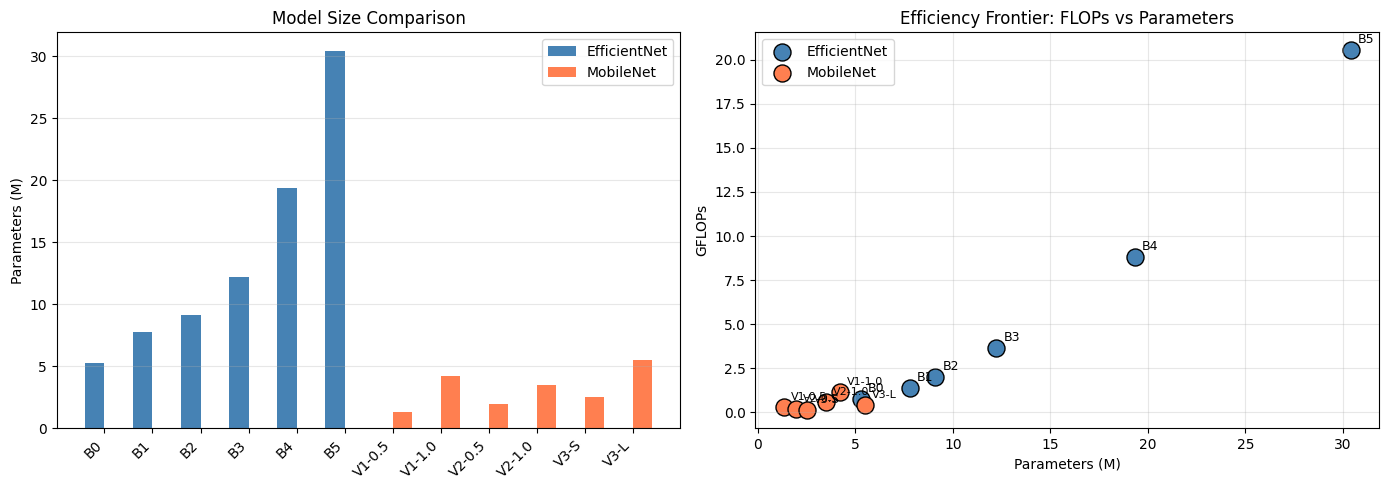

In [12]:
# Visualize scaling

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Collect data for all EfficientNet variants
variants = ['b0', 'b1', 'b2', 'b3', 'b4', 'b5']
eff_params = []
eff_flops = []

for v in variants:
    model = EfficientNet(variant=v)
    cfg = model.config
    eff_params.append(count_parameters(model) / 1e6)
    eff_flops.append(count_flops(model, (3, cfg.resolution, cfg.resolution)) / 1e9)

# MobileNet variants for comparison
mobile_configs = [
    ('V1-0.5', MobileNetV1(width_mult=0.5)),
    ('V1-1.0', MobileNetV1(width_mult=1.0)),
    ('V2-0.5', MobileNetV2(width_mult=0.5)),
    ('V2-1.0', MobileNetV2(width_mult=1.0)),
    ('V3-S', MobileNetV3(mode='small')),
    ('V3-L', MobileNetV3(mode='large')),
]

mobile_names = [c[0] for c in mobile_configs]
mobile_params = [count_parameters(c[1]) / 1e6 for c in mobile_configs]
mobile_flops = [count_flops(c[1], (3, 224, 224)) / 1e9 for c in mobile_configs]

# Plot 1: Parameters comparison
ax = axes[0]
x = np.arange(len(variants))
ax.bar(x - 0.2, eff_params, 0.4, label='EfficientNet', color='steelblue')
ax.bar(np.arange(len(mobile_names)) + 0.2 + len(variants), mobile_params, 0.4,
       label='MobileNet', color='coral')
ax.set_xticks(list(range(len(variants))) + list(range(len(variants), len(variants) + len(mobile_names))))
ax.set_xticklabels([f'B{i}' for i in range(len(variants))] + mobile_names, rotation=45, ha='right')
ax.set_ylabel('Parameters (M)')
ax.set_title('Model Size Comparison')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Plot 2: FLOPs vs Parameters (efficiency frontier)
ax = axes[1]
ax.scatter(eff_params, eff_flops, s=150, c='steelblue', label='EfficientNet', edgecolors='black')
ax.scatter(mobile_params, mobile_flops, s=150, c='coral', label='MobileNet', edgecolors='black')

# Add labels
for i, v in enumerate(variants):
    ax.annotate(f'B{i}', (eff_params[i], eff_flops[i]), textcoords="offset points",
                xytext=(5, 5), fontsize=9)
for i, n in enumerate(mobile_names):
    ax.annotate(n, (mobile_params[i], mobile_flops[i]), textcoords="offset points",
                xytext=(5, 5), fontsize=8)

ax.set_xlabel('Parameters (M)')
ax.set_ylabel('GFLOPs')
ax.set_title('Efficiency Frontier: FLOPs vs Parameters')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('efficient_cnn_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

Experimental Comparison

In [13]:
# Prepare CIFAR-10 data

transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

train_dataset = datasets.CIFAR10('./data', train=True, download=True, transform=transform_train)
test_dataset = datasets.CIFAR10('./data', train=False, transform=transform_test)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=256, num_workers=2)

print(f"CIFAR-10: Train={len(train_dataset)}, Test={len(test_dataset)}")

100%|██████████| 170M/170M [00:02<00:00, 75.9MB/s]


CIFAR-10: Train=50000, Test=10000


In [14]:
# Adapt models for CIFAR-10 (32x32 input)

def adapt_for_cifar(model_class, **kwargs):
    """Create CIFAR-10 adapted version of a model."""
    model = model_class(num_classes=10, **kwargs)

    # Modify first conv to not downsample as aggressively
    if hasattr(model, 'first_conv'):
        # Change stride from 2 to 1
        old_conv = model.first_conv[0]
        model.first_conv[0] = nn.Conv2d(
            old_conv.in_channels, old_conv.out_channels,
            kernel_size=3, stride=1, padding=1, bias=False
        )
    elif hasattr(model, 'stem'):
        old_conv = model.stem[0]
        model.stem[0] = nn.Conv2d(
            old_conv.in_channels, old_conv.out_channels,
            kernel_size=3, stride=1, padding=1, bias=False
        )

    return model


def train_and_evaluate(model, name, epochs=10, lr=0.01):
    """Train and evaluate a model on CIFAR-10."""
    model = model.to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, epochs)

    params = count_parameters(model)
    flops = count_flops(model.cpu(), (3, 32, 32))
    model = model.to(device)

    print(f"\n{name}: {params/1e6:.2f}M params, {flops/1e6:.1f}M FLOPs")

    best_acc = 0
    train_times = []

    for epoch in range(epochs):
        model.train()
        start = time.perf_counter()

        for data, target in train_loader:
            data, target = data.to(device), target.to(device)
            optimizer.zero_grad()
            loss = F.cross_entropy(model(data), target)
            loss.backward()
            optimizer.step()

        scheduler.step()
        train_times.append(time.perf_counter() - start)

        # Evaluate
        model.eval()
        correct = 0
        with torch.no_grad():
            for data, target in test_loader:
                data, target = data.to(device), target.to(device)
                correct += model(data).argmax(1).eq(target).sum().item()

        acc = correct / len(test_dataset)
        best_acc = max(best_acc, acc)

        if (epoch + 1) % 2 == 0:
            print(f"  Epoch {epoch+1:2d}: {100*acc:.2f}% (best: {100*best_acc:.2f}%)")

    return {
        'params': params,
        'flops': flops,
        'accuracy': best_acc,
        'avg_epoch_time': np.mean(train_times)
    }

In [15]:
# Train models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 70)
print("CIFAR-10 TRAINING")
print("=" * 70)

models_to_train = [
    ('MobileNetV1-0.5', lambda: adapt_for_cifar(MobileNetV1, width_mult=0.5)),
    ('MobileNetV2-0.5', lambda: adapt_for_cifar(MobileNetV2, width_mult=0.5)),
    ('MobileNetV3-Small', lambda: adapt_for_cifar(MobileNetV3, mode='small', width_mult=0.75)),
    ('EfficientNet-B0', lambda: adapt_for_cifar(EfficientNet, variant='b0')),
]

results = {}
for name, model_fn in models_to_train:
    model = model_fn()
    results[name] = train_and_evaluate(model, name, epochs=10)

CIFAR-10 TRAINING

MobileNetV1-0.5: 0.82M params, 24.3M FLOPs
  Epoch  2: 45.84% (best: 45.84%)
  Epoch  4: 55.05% (best: 55.05%)
  Epoch  6: 60.54% (best: 60.54%)
  Epoch  8: 63.87% (best: 63.87%)
  Epoch 10: 65.07% (best: 65.07%)

MobileNetV2-0.5: 0.70M params, 15.7M FLOPs
  Epoch  2: 41.02% (best: 41.02%)
  Epoch  4: 58.32% (best: 58.32%)
  Epoch  6: 64.09% (best: 64.09%)
  Epoch  8: 66.33% (best: 66.33%)
  Epoch 10: 67.61% (best: 67.70%)

MobileNetV3-Small: 1.03M params, 8.3M FLOPs
  Epoch  2: 51.17% (best: 51.17%)
  Epoch  4: 62.34% (best: 62.34%)
  Epoch  6: 66.23% (best: 66.23%)
  Epoch  8: 70.16% (best: 70.16%)
  Epoch 10: 71.09% (best: 71.09%)

EfficientNet-B0: 4.02M params, 64.0M FLOPs
  Epoch  2: 58.41% (best: 58.41%)
  Epoch  4: 70.76% (best: 70.76%)
  Epoch  6: 74.83% (best: 74.83%)
  Epoch  8: 78.17% (best: 78.17%)
  Epoch 10: 78.80% (best: 78.80%)


In [16]:
# Results summary

print("\n" + "=" * 80)
print("RESULTS SUMMARY")
print("=" * 80)

print(f"\n{'Model':<22} {'Params':>10} {'MFLOPs':>10} {'Accuracy':>10} {'Time/Epoch':>12}")
print("-" * 70)

for name, r in results.items():
    print(f"{name:<22} {r['params']/1e6:>9.2f}M {r['flops']/1e6:>9.1f} "
          f"{100*r['accuracy']:>9.2f}% {r['avg_epoch_time']:>11.1f}s")


RESULTS SUMMARY

Model                      Params     MFLOPs   Accuracy   Time/Epoch
----------------------------------------------------------------------
MobileNetV1-0.5             0.82M      24.3     65.07%        10.5s
MobileNetV2-0.5             0.70M      15.7     67.70%        11.9s
MobileNetV3-Small           1.03M       8.3     71.09%        10.8s
EfficientNet-B0             4.02M      64.0     78.80%        27.9s


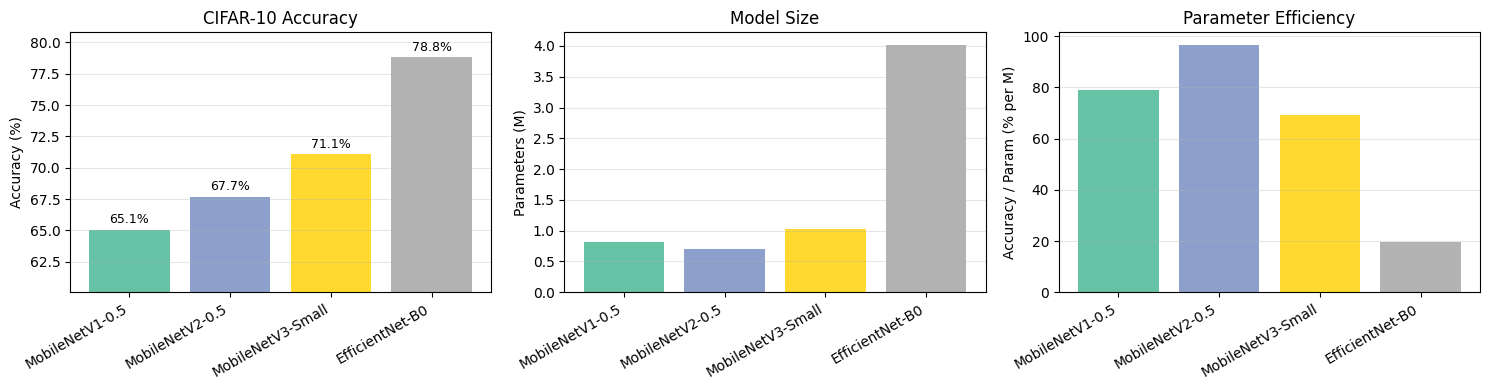

In [17]:
# Final visualization

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

names = list(results.keys())
params = [results[n]['params'] / 1e6 for n in names]
flops = [results[n]['flops'] / 1e6 for n in names]
accs = [results[n]['accuracy'] * 100 for n in names]
times = [results[n]['avg_epoch_time'] for n in names]

colors = plt.cm.Set2(np.linspace(0, 1, len(names)))

# Plot 1: Accuracy
ax = axes[0]
bars = ax.bar(range(len(names)), accs, color=colors)
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=30, ha='right')
ax.set_ylabel('Accuracy (%)')
ax.set_title('CIFAR-10 Accuracy')
ax.set_ylim(min(accs) - 5, max(accs) + 2)
for i, a in enumerate(accs):
    ax.text(i, a + 0.5, f'{a:.1f}%', ha='center', fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

# Plot 2: Parameters
ax = axes[1]
ax.bar(range(len(names)), params, color=colors)
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=30, ha='right')
ax.set_ylabel('Parameters (M)')
ax.set_title('Model Size')
ax.grid(True, alpha=0.3, axis='y')

# Plot 3: Efficiency (Accuracy per MParam)
ax = axes[2]
efficiency = [a / p for a, p in zip(accs, params)]
ax.bar(range(len(names)), efficiency, color=colors)
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=30, ha='right')
ax.set_ylabel('Accuracy / Param (% per M)')
ax.set_title('Parameter Efficiency')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('mobilenet_efficientnet_results.png', dpi=150, bbox_inches='tight')
plt.show()